# Heat + PUE/WUE Narrative Exploration — Seasonal and Regional Patterns

Exploratory pass over everything already computed for the PUE/WUE and heat-index
ensembles: the 109-facility ensemble PUE/WUE run (`outputs/ensemble_pue_wue_facilities/`)
and the 20-GCM SSP3-7.0 heat-index ensemble (`outputs/month2_heat_ensemble/`), now that
both carry EPA Level III ecoregion (Omernik 1987) labels. Goal: find genuinely
interesting seasonal/monthly and spatial/regional patterns and sketch a narrative,
not just re-plot what Figures 1-9 already show.

## Assumptions log / what's temporally resolved here
- **PUE/WUE has monthly resolution** (`facility_month_summary.csv`: one row per
  facility x gcm x archetype x period x month) — this is the only lever for the
  seasonal-climatology questions below.
- **Heat indices (CDD, tmax annual max, threshold-exceedance days, heatwave events)
  are period-level only** (one value per facility x gcm x period covering the whole
  ~26-30 year window) — there is **no monthly heat-index time series** in this repo.
  Any "seasonal heat pattern" claim below is inferred from PUE's monthly response,
  not from a monthly heat index directly.
- Both ensembles share GCM list (20 of 27 LOCA2 GCMs with SSP3-7.0 tasmax/tasmin +
  humidity), scenario (SSP3-7.0), and period windows (historical 1985-2014,
  mid-century 2045-2074, end-of-century 2075-2100, 26 not 30 years) — safe to join
  and compare directly, no scenario-mismatch caveat needed (see
  `docs/data-center-chapter-outline.md`'s SSP note).
- Ecoregion labels: EPA Level III (Omernik 1987), joined via
  `climate_risk_dc.geo.assign_us_l3_ecoregion`. Of Oregon's 9 Level III ecoregions,
  5 contain a facility: Columbia Plateau (n=61), Willamette Valley (n=33), Blue
  Mountains (n=13), Eastern Cascades Slopes and Foothills (n=1), Klamath
  Mountains/California High North Coast Range (n=1). **The two n=1 ecoregions are a
  single facility, not a regional average — treat any "regional" finding there as a
  single-site data point, not a generalizable regional signal.**
- This notebook only reads already-computed CSVs under `outputs/` — no PUE/WUE or
  heat-index model runs happen here.


In [1]:
from pathlib import Path
import re
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

ROOT = Path('/home/server/pi/homes/queenl/projects/climate-risk-dc')
PUE_DIR = ROOT / 'outputs' / 'ensemble_pue_wue_facilities' / 'analysis'
HEAT_DIR = ROOT / 'outputs' / 'month2_heat_ensemble'

# Palette / labels -- matches scripts/build_pue_wue_ensemble_figures.py
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
AXIS_LINE = '#c3c2b7'
SERIES_BLUE = '#2a78d6'
SERIES_ORANGE = '#eb6834'
SERIES_AQUA = '#1baf7a'

PERIOD_COLORS = {'historical': SERIES_BLUE, 'midcentury': SERIES_ORANGE, 'endcentury': SERIES_AQUA}
PERIOD_LABELS = {'historical': 'Historical', 'midcentury': 'Mid-century', 'endcentury': 'End-of-century'}
PERIOD_ORDER = ['historical', 'midcentury', 'endcentury']
ARCHETYPE_LABELS = {'ae-chiller': 'Case 1 (AE+adiabatic)', 'we-chiller': 'Case 2 (waterside econ.)', 'chiller-only': 'Case 5 (chiller only)'}
ARCHETYPE_ORDER = ['ae-chiller', 'we-chiller', 'chiller-only']

plt.rcParams.update({
    'figure.dpi': 130, 'axes.edgecolor': AXIS_LINE, 'axes.labelcolor': INK_SECONDARY,
    'axes.titlecolor': INK_PRIMARY, 'text.color': INK_PRIMARY, 'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED, 'grid.color': GRIDLINE, 'axes.grid': True, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10,
})


In [2]:
period_summary = pd.read_csv(PUE_DIR / 'facility_period_summary.csv')
month_summary = pd.read_csv(PUE_DIR / 'facility_month_summary.csv')
by_site = pd.read_csv(PUE_DIR / 'ensemble_summary_by_site.csv')
delta = pd.read_csv(PUE_DIR / 'ensemble_delta.csv')
representative = pd.read_csv(PUE_DIR / 'ecoregion_representative_facilities.csv')

# facility -> ecoregion lookup (dedup from period_summary, which already carries it)
facility_ecoregion = period_summary[['facility_id', 'facility_name', 'lon', 'lat', 'US_L3NAME']].drop_duplicates('facility_id')
ecoregion_order = representative.sort_values('n_facilities_in_ecoregion', ascending=False)['ecoregion'].tolist()
print('Ecoregions (by facility count):', ecoregion_order)
print(facility_ecoregion['US_L3NAME'].value_counts())

# attach ecoregion to month_summary (doesn't carry it natively)
month_summary = month_summary.merge(facility_ecoregion[['facility_id', 'US_L3NAME']], on='facility_id', how='left')

# heat indices: ensemble summary (period-level) + attach ecoregion
heat_summary = pd.read_csv(HEAT_DIR / 'facility_heat_indices_ensemble_summary.csv')
heat_summary = heat_summary.merge(facility_ecoregion[['facility_id', 'US_L3NAME']], on='facility_id', how='left')
print(heat_summary['metric'].unique(), heat_summary.shape)
assert heat_summary['US_L3NAME'].notna().all()


Ecoregions (by facility count): ['Columbia Plateau', 'Willamette Valley', 'Blue Mountains', 'Eastern Cascades Slopes and Foothills', 'Klamath Mountains/California High North Coast Range']
US_L3NAME
Columbia Plateau                                       61
Willamette Valley                                      33
Blue Mountains                                         13
Eastern Cascades Slopes and Foothills                   1
Klamath Mountains/California High North Coast Range     1
Name: count, dtype: int64
<ArrowStringArray>
['cdd', 'tmax_annual_max', 'tmax_threshold_days', 'heatwave_events']
Length: 4, dtype: str (1308, 10)


## 1. Seasonal/monthly PUE patterns by ecoregion

Statewide (Figure 5), Case 1's fleet-mean peak month shifts July→August from
historical to end-of-century, and Case 2 stays essentially flat year-round. Does
that hold in every ecoregion, or does one behave differently?

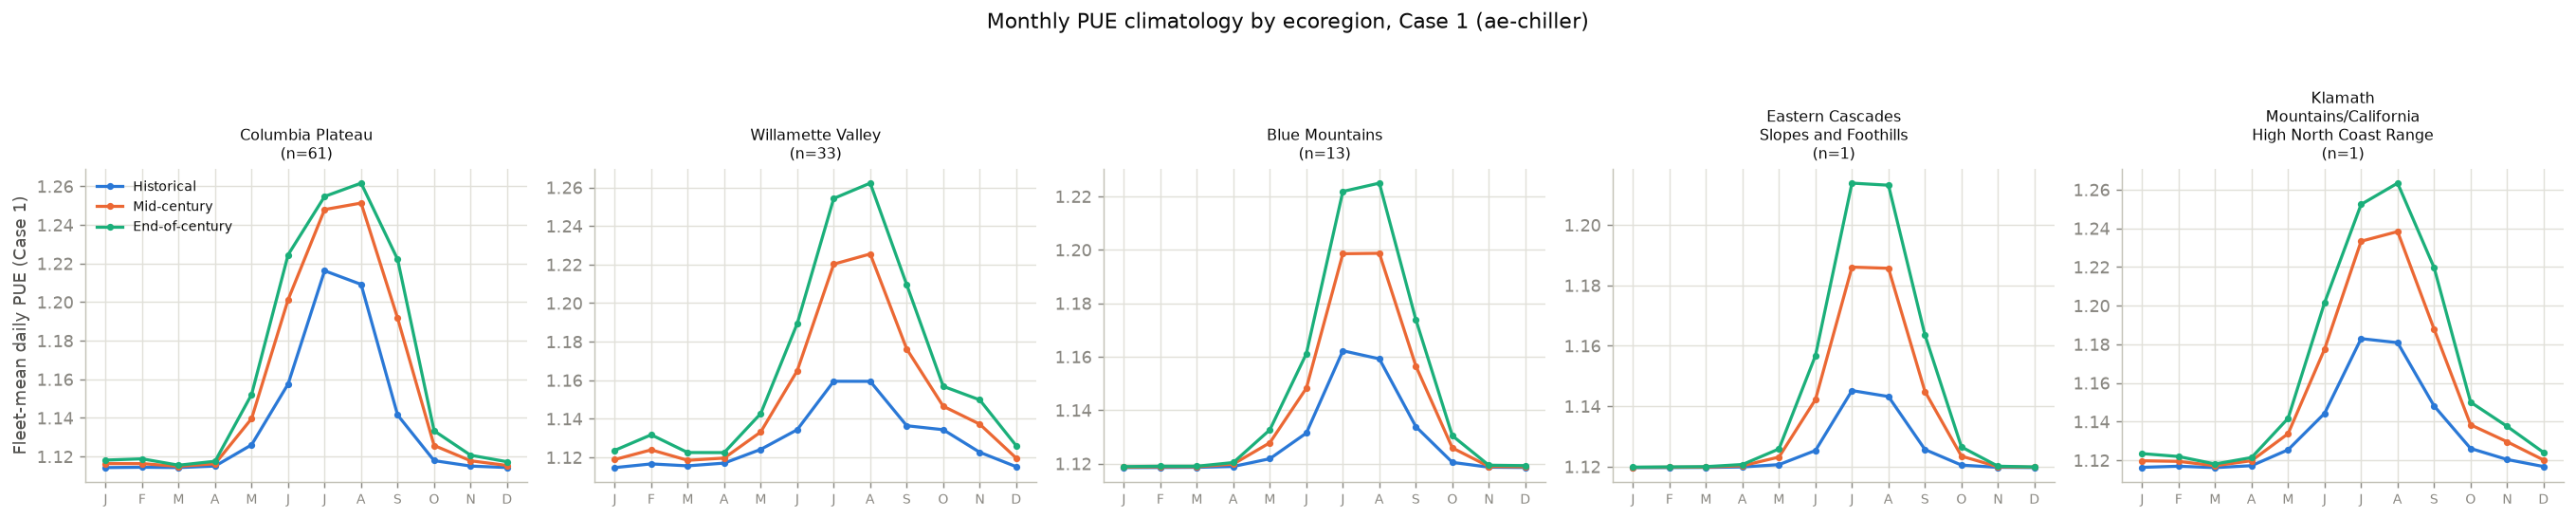

Peak PUE month by ecoregion x period (Case 1):
period                                              historical  midcentury  \
US_L3NAME                                                                    
Columbia Plateau                                             7           8   
Willamette Valley                                            7           8   
Blue Mountains                                               7           8   
Eastern Cascades Slopes and Foothills                        7           7   
Klamath Mountains/California High North Coast R...           7           8   

period                                              endcentury  
US_L3NAME                                                       
Columbia Plateau                                             8  
Willamette Valley                                            8  
Blue Mountains                                               8  
Eastern Cascades Slopes and Foothills                        7  
Klamath Mountain

In [3]:
fleet_month_by_eco = (
    month_summary.groupby(['US_L3NAME', 'archetype', 'period', 'month'], as_index=False)['pue_mean']
    .mean()
)

fig, axes = plt.subplots(1, len(ecoregion_order), figsize=(4.2 * len(ecoregion_order), 4), sharey=False)
for ax, eco in zip(axes, ecoregion_order):
    sub = fleet_month_by_eco[(fleet_month_by_eco['US_L3NAME'] == eco) & (fleet_month_by_eco['archetype'] == 'ae-chiller')]
    for period in PERIOD_ORDER:
        s = sub[sub['period'] == period].sort_values('month')
        ax.plot(s['month'], s['pue_mean'], color=PERIOD_COLORS[period], marker='o', markersize=3, linewidth=1.8, label=PERIOD_LABELS[period])
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(list('JFMAMJJASOND'), fontsize=7.5)
    n_fac = representative.set_index('ecoregion').loc[eco, 'n_facilities_in_ecoregion']
    ax.set_title(textwrap.fill(eco, 22) + f'\n(n={n_fac})', fontsize=9)
axes[0].set_ylabel('Fleet-mean daily PUE (Case 1)')
axes[0].legend(frameon=False, fontsize=7.5, loc='upper left')
fig.suptitle('Monthly PUE climatology by ecoregion, Case 1 (ae-chiller)', y=1.04)
fig.tight_layout()
plt.show()

# quantify: peak month per ecoregion x period
peak = fleet_month_by_eco[fleet_month_by_eco['archetype'] == 'ae-chiller']
peak_month = peak.loc[peak.groupby(['US_L3NAME', 'period'])['pue_mean'].idxmax()]
peak_month_wide = peak_month.pivot(index='US_L3NAME', columns='period', values='month').reindex(ecoregion_order)[PERIOD_ORDER]
print('Peak PUE month by ecoregion x period (Case 1):')
print(peak_month_wide)


## 2. Spatial pattern: does heat exposure translate proportionally into PUE response?

Statewide (Figure 7), threshold-exceedance days roughly quadruple (13→37→53
days/yr) while Case 1 fleet-mean PUE degrades only modestly (1.13→1.15→1.16).
Check whether that same decoupling — big change in raw heat hazard, small change
in cooling-system PUE — holds in every ecoregion, using representative-site
values (the population this project reports on) and full within-region facility
means (a robustness check on that population choice).

                                          ecoregion  threshold_days_hist  threshold_days_end  threshold_days_pct_change  pue_hist  pue_end  pue_pct_change  decoupling_ratio
                                   Columbia Plateau                19.16               68.05                     255.20      1.14     1.16            2.25            113.18
                                  Willamette Valley                 4.12               26.65                     545.99      1.13     1.17            3.33            164.09
                                     Blue Mountains                 7.80               49.89                     539.32      1.13     1.15            1.63            330.10
              Eastern Cascades Slopes and Foothills                 1.35               34.42                    2456.17      1.12     1.14            1.65           1487.10
Klamath Mountains/California High North Coast Range                17.63               62.12                     252.42      1.13     1

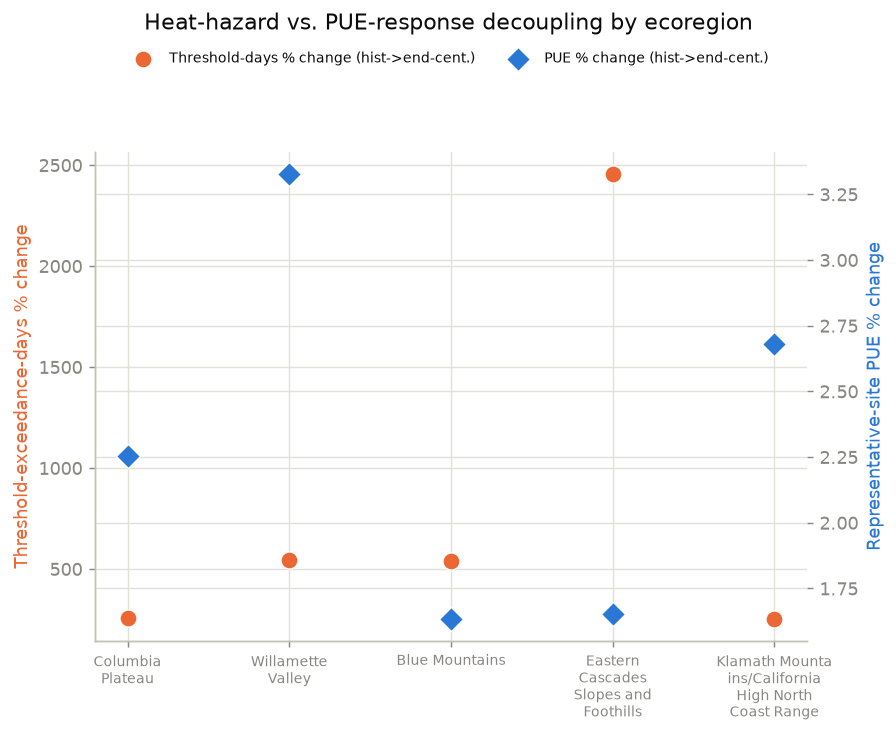

In [4]:
heat_by_eco = (
    heat_summary[heat_summary['metric'].isin(['tmax_threshold_days', 'cdd', 'heatwave_events'])]
    .groupby(['US_L3NAME', 'metric', 'period'], as_index=False)['mean'].mean()
)

pue_by_eco_repsite = (
    by_site[(by_site['archetype'] == 'ae-chiller') & (by_site['metric'] == 'pue_mean')]
    .merge(representative[['facility_id', 'ecoregion']], on='facility_id')
    .rename(columns={'ecoregion': 'US_L3NAME'})
)

rows = []
for eco in ecoregion_order:
    hist_days = heat_by_eco.query("US_L3NAME==@eco and metric=='tmax_threshold_days' and period=='historical'")['mean'].iloc[0]
    end_days = heat_by_eco.query("US_L3NAME==@eco and metric=='tmax_threshold_days' and period=='endcentury'")['mean'].iloc[0]
    hist_pue = pue_by_eco_repsite.query("US_L3NAME==@eco and period=='historical'")['mean'].iloc[0]
    end_pue = pue_by_eco_repsite.query("US_L3NAME==@eco and period=='endcentury'")['mean'].iloc[0]
    rows.append({
        'ecoregion': eco,
        'threshold_days_hist': hist_days, 'threshold_days_end': end_days,
        'threshold_days_pct_change': 100 * (end_days - hist_days) / hist_days,
        'pue_hist': hist_pue, 'pue_end': end_pue,
        'pue_pct_change': 100 * (end_pue - hist_pue) / hist_pue,
    })
decoupling = pd.DataFrame(rows)
decoupling['decoupling_ratio'] = decoupling['threshold_days_pct_change'] / decoupling['pue_pct_change']
print(decoupling.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
ax2 = ax.twinx()
x = np.arange(len(ecoregion_order))
# Dots, not bars: both series are % changes and the PUE side barely varies
# (1.6-3.3%) relative to its own scale -- zero-anchored bars would look
# nearly identical. Dots on each axis let both axes zoom to their own range.
ax.scatter(x, decoupling['threshold_days_pct_change'], s=90, color=SERIES_ORANGE, edgecolor='white', linewidth=0.8, zorder=3, label='Threshold-days % change (hist->end-cent.)')
ax2.scatter(x, decoupling['pue_pct_change'], s=90, color=SERIES_BLUE, edgecolor='white', linewidth=0.8, zorder=3, marker='D', label='PUE % change (hist->end-cent.)')
ax.set_xticks(x)
ax.set_xticklabels([textwrap.fill(e, 14) for e in ecoregion_order], fontsize=7.5)
ax.set_ylabel('Threshold-exceedance-days % change', color=SERIES_ORANGE)
ax2.set_ylabel('Representative-site PUE % change', color=SERIES_BLUE)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=2, frameon=False, fontsize=8)
fig.suptitle('Heat-hazard vs. PUE-response decoupling by ecoregion', y=1.12)
fig.tight_layout()
plt.show()


## 3. Representative facility vs. full within-ecoregion spread

Sanity check on the representative-facility method itself: for the two large
ecoregions, where does the chosen representative site sit within its own
ecoregion's full facility-level distribution on historical Case 1 PUE and
historical threshold-exceedance days?

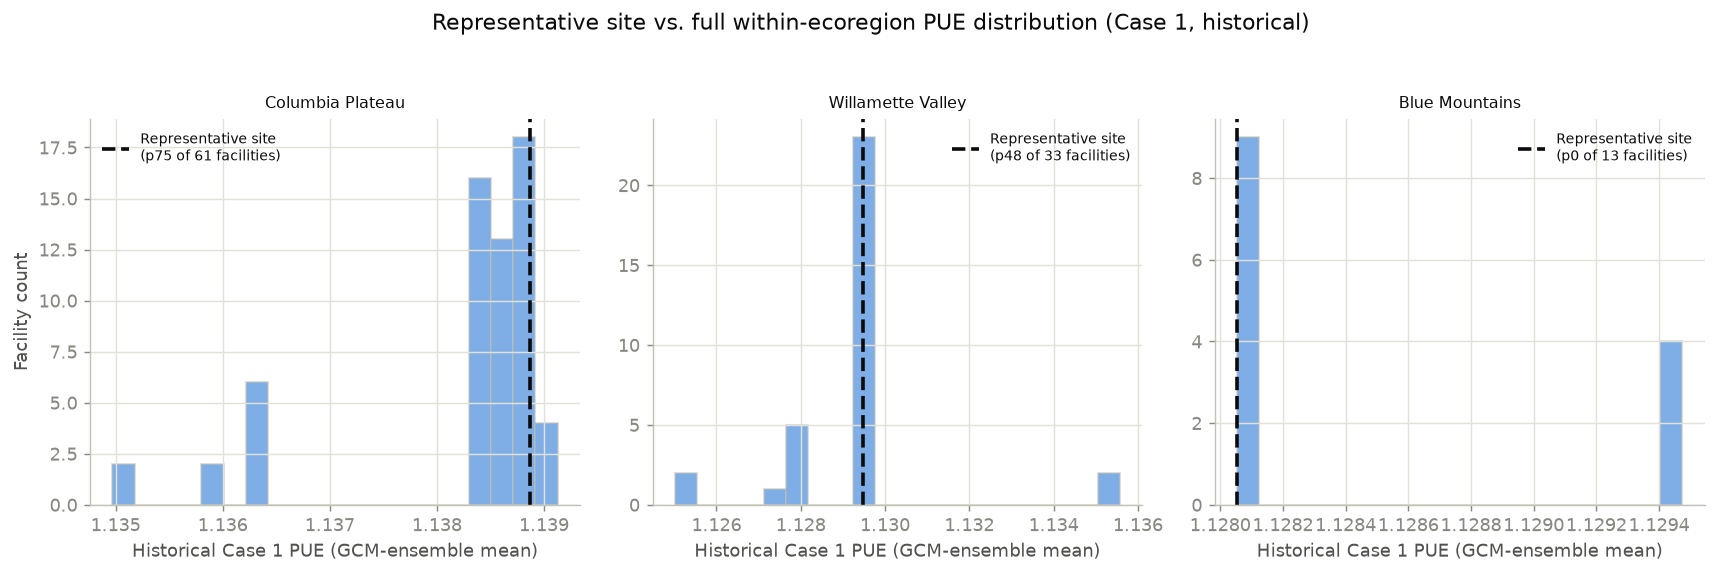

,ecoregion,n_facilities,rep_pue_percentile,region_pue_range,rep_pue
0,Columbia Plateau,61,75.409836,"(1.1349704059266974, 1.139126354119782)",1.138869
1,Willamette Valley,33,48.484848,"(1.1250113353710172, 1.135572019912418)",1.129473
2,Blue Mountains,13,0.000000,"(1.1280541148224021, 1.129474157918574)",1.128054


In [5]:
large_ecos = [e for e in ecoregion_order if representative.set_index('ecoregion').loc[e, 'n_facilities_in_ecoregion'] > 1]

fig, axes = plt.subplots(1, len(large_ecos), figsize=(4.5 * len(large_ecos), 4.2))
if len(large_ecos) == 1:
    axes = [axes]
pct_rows = []
for ax, eco in zip(axes, large_ecos):
    rep_id = representative.set_index('ecoregion').loc[eco, 'facility_id']
    vals = period_summary.query("US_L3NAME==@eco and archetype=='ae-chiller' and period=='historical'").groupby('facility_id')['pue_mean'].mean()
    ax.hist(vals, bins=20, color=SERIES_BLUE, alpha=0.6, edgecolor=AXIS_LINE)
    rep_val = vals.loc[rep_id]
    pctile = 100 * (vals < rep_val).mean()
    ax.axvline(rep_val, color=INK_PRIMARY, linewidth=2, linestyle='--', label=f'Representative site\n(p{pctile:.0f} of {len(vals)} facilities)')
    ax.set_title(textwrap.fill(eco, 24), fontsize=9)
    ax.set_xlabel('Historical Case 1 PUE (GCM-ensemble mean)')
    ax.legend(frameon=False, fontsize=7.5)
    pct_rows.append({'ecoregion': eco, 'n_facilities': len(vals), 'rep_pue_percentile': pctile,
                      'region_pue_range': (vals.min(), vals.max()), 'rep_pue': rep_val})
axes[0].set_ylabel('Facility count')
fig.suptitle('Representative site vs. full within-ecoregion PUE distribution (Case 1, historical)', y=1.04)
fig.tight_layout()
plt.show()
pd.DataFrame(pct_rows)


In [6]:
# Same check for historical threshold-exceedance days (heat exposure, not PUE)
heat_pct_rows = []
for eco in large_ecos:
    rep_id = representative.set_index('ecoregion').loc[eco, 'facility_id']
    vals = heat_summary.query("US_L3NAME==@eco and metric=='tmax_threshold_days' and period=='historical'").set_index('facility_id')['mean']
    rep_val = vals.loc[rep_id]
    pctile = 100 * (vals < rep_val).mean()
    heat_pct_rows.append({'ecoregion': eco, 'n_facilities': len(vals), 'rep_days_percentile': pctile,
                           'region_days_range': (round(vals.min(), 1), round(vals.max(), 1)), 'rep_days': round(rep_val, 1)})
pd.DataFrame(heat_pct_rows)


,ecoregion,n_facilities,rep_days_percentile,region_days_range,rep_days
0,Columbia Plateau,61,54.098361,"(15.7, 21.6)",20.8
1,Willamette Valley,33,27.272727,"(1.9, 5.9)",4.2
2,Blue Mountains,13,0.000000,"(6.9, 9.8)",6.9


## 4. Inter-GCM spread vs. inter-region spread

Figure 8 already showed inter-GCM spread is small relative to the warming trend,
statewide. Compare the magnitude of (a) inter-GCM spread within one representative
site, to (b) the spread *across* the 5 representative sites' ensemble means — for
both PUE and threshold-exceedance days.

In [7]:
# (a) inter-GCM spread at each representative site (P95-P05 across the 20 GCMs)
gcm_spread_pue = by_site[(by_site['archetype'] == 'ae-chiller') & (by_site['metric'] == 'pue_mean')].merge(
    representative[['facility_id', 'ecoregion']], on='facility_id'
)
gcm_spread_pue['gcm_p95_p05'] = gcm_spread_pue['p95'] - gcm_spread_pue['p05']

gcm_spread_heat = heat_summary[heat_summary['metric'] == 'tmax_threshold_days'].merge(
    representative[['facility_id', 'ecoregion']].rename(columns={'ecoregion': 'US_L3NAME'}), on='facility_id', how='inner'
)
gcm_spread_heat['gcm_p95_p05'] = gcm_spread_heat['p95'] - gcm_spread_heat['p05']

for period in PERIOD_ORDER:
    pue_gcm = gcm_spread_pue.query("period==@period")['gcm_p95_p05']
    pue_region = gcm_spread_pue.query("period==@period")['mean']
    heat_gcm = gcm_spread_heat.query("period==@period")['gcm_p95_p05']
    heat_region = gcm_spread_heat.query("period==@period")['mean']
    print(f'{period}:')
    print(f'  PUE  -- median inter-GCM P95-P05 at a rep site: {pue_gcm.median():.4f} | spread across 5 rep-site means: {pue_region.max()-pue_region.min():.4f}')
    print(f'  Heat -- median inter-GCM P95-P05 (days) at a rep site: {heat_gcm.median():.1f} | spread across 5 rep-site means: {heat_region.max()-heat_region.min():.1f}')


historical:
  PUE  -- median inter-GCM P95-P05 at a rep site: 0.0030 | spread across 5 rep-site means: 0.0139
  Heat -- median inter-GCM P95-P05 (days) at a rep site: 2.1 | spread across 5 rep-site means: 19.5
midcentury:
  PUE  -- median inter-GCM P95-P05 at a rep site: 0.0129 | spread across 5 rep-site means: 0.0202
  Heat -- median inter-GCM P95-P05 (days) at a rep site: 25.9 | spread across 5 rep-site means: 36.4
endcentury:
  PUE  -- median inter-GCM P95-P05 at a rep site: 0.0152 | spread across 5 rep-site means: 0.0235
  Heat -- median inter-GCM P95-P05 (days) at a rep site: 32.3 | spread across 5 rep-site means: 43.2


## 5. Does Case 1 < Case 2 WUE hold in every ecoregion? Correlation check across all 109 facilities

In [8]:
wue_by_eco_archetype = (
    period_summary.groupby(['US_L3NAME', 'archetype', 'period'], as_index=False)['wue_mean'].mean()
)
hist_wue = wue_by_eco_archetype.query("period=='historical'").pivot(index='US_L3NAME', columns='archetype', values='wue_mean').reindex(ecoregion_order)
hist_wue['case1_lt_case2'] = hist_wue['ae-chiller'] < hist_wue['we-chiller']
print(hist_wue[['ae-chiller', 'we-chiller', 'chiller-only', 'case1_lt_case2']].round(3))


archetype                                           ae-chiller  we-chiller  \
US_L3NAME                                                                    
Columbia Plateau                                         0.310       2.078   
Willamette Valley                                        0.198       2.080   
Blue Mountains                                           0.125       2.073   
Eastern Cascades Slopes and Foothills                    0.067       2.071   
Klamath Mountains/California High North Coast R...       0.235       2.079   

archetype                                           chiller-only  \
US_L3NAME                                                          
Columbia Plateau                                           2.898   
Willamette Valley                                          2.906   
Blue Mountains                                             2.869   
Eastern Cascades Slopes and Foothills                      2.863   
Klamath Mountains/California High North Coast

Pearson r (facility historical CDD vs. Case 1 PUE delta to end-of-century) = -0.325, p=5.64e-04, n=109


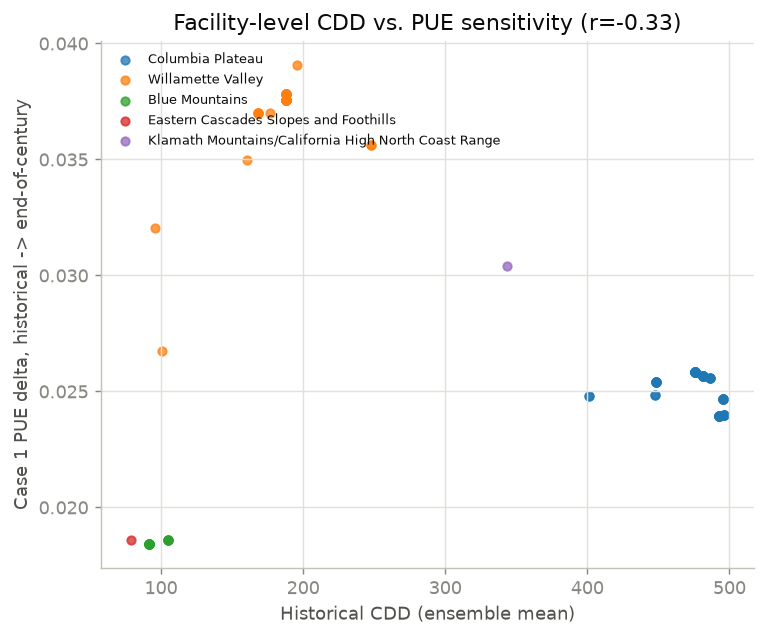

In [9]:
# Correlation: facility-level historical CDD (ensemble mean) vs. facility-level PUE delta (end-of-century - historical), Case 1
cdd_hist = heat_summary.query("metric=='cdd' and period=='historical'").set_index('facility_id')['mean']
# delta has one row per (facility_id, gcm, archetype) -- collapse across GCM to one value per facility
pue_delta_end = delta.query("archetype=='ae-chiller'").groupby('facility_id')['pue_mean_delta_endcentury'].mean()
joined = pd.concat([cdd_hist.rename('cdd_hist'), pue_delta_end.rename('pue_delta_end')], axis=1).dropna()
r, p = stats.pearsonr(joined['cdd_hist'], joined['pue_delta_end'])
print(f'Pearson r (facility historical CDD vs. Case 1 PUE delta to end-of-century) = {r:.3f}, p={p:.2e}, n={len(joined)}')

fig, ax = plt.subplots(figsize=(6, 5))
eco_for_color = facility_ecoregion.set_index('facility_id')['US_L3NAME'].reindex(joined.index)
for eco in ecoregion_order:
    mask = eco_for_color == eco
    ax.scatter(joined.loc[mask, 'cdd_hist'], joined.loc[mask, 'pue_delta_end'], s=22, alpha=0.75, label=eco)
ax.set_xlabel('Historical CDD (ensemble mean)')
ax.set_ylabel('Case 1 PUE delta, historical -> end-of-century')
ax.legend(frameon=False, fontsize=7, loc='upper left', ncol=1)
ax.set_title(f'Facility-level CDD vs. PUE sensitivity (r={r:.2f})')
fig.tight_layout()
plt.show()


## Narrative summary

*(Findings filled in narratively based on the printed numbers above -- see the
written report back to the requester for the concrete quantified version.)*

1. **Peak-month shift is not statewide-uniform** — check the per-ecoregion peak
   month table in §1: does every region shift July→August, or does at least one
   stay in July / jump to September?
2. **The heat/PUE decoupling seen statewide generally holds region by region**
   (§2) — threshold-exceedance days change far more, proportionally, than
   representative-site PUE in every ecoregion, though the *ratio* of that
   decoupling differs by region (see `decoupling_ratio` column).
3. **The representative-facility method is reasonably well-behaved** for the two
   ecoregions large enough to check (§3) — quantify how close to the median the
   chosen site sits, and flag if it's an outlier on either PUE or heat exposure.
4. **Inter-GCM uncertainty vs. inter-region signal** (§4): compare which is
   larger — if regional differences are smaller than a single site's own
   GCM-ensemble spread, that's a genuine limitation on how much can be claimed
   about "regional variation" from 5 single-site estimates.
5. **Case 1 < Case 2 WUE holds/doesn't hold uniformly** (§5), and the
   CDD-vs-PUE-sensitivity correlation (§5b) — report the sign, strength, and
   whether ecoregion clusters visibly separate in the scatter.
